# Example offline QRS detector usage

In [1]:
from QRSDetectorOffline import QRSDetectorOffline

## ECG signal with low level of noise

qrs peaks indices
[ 194  390  581  768  955 1142 1329 1515 1701 1886 2070 2253 2434 2616]
noise peaks indices
[]


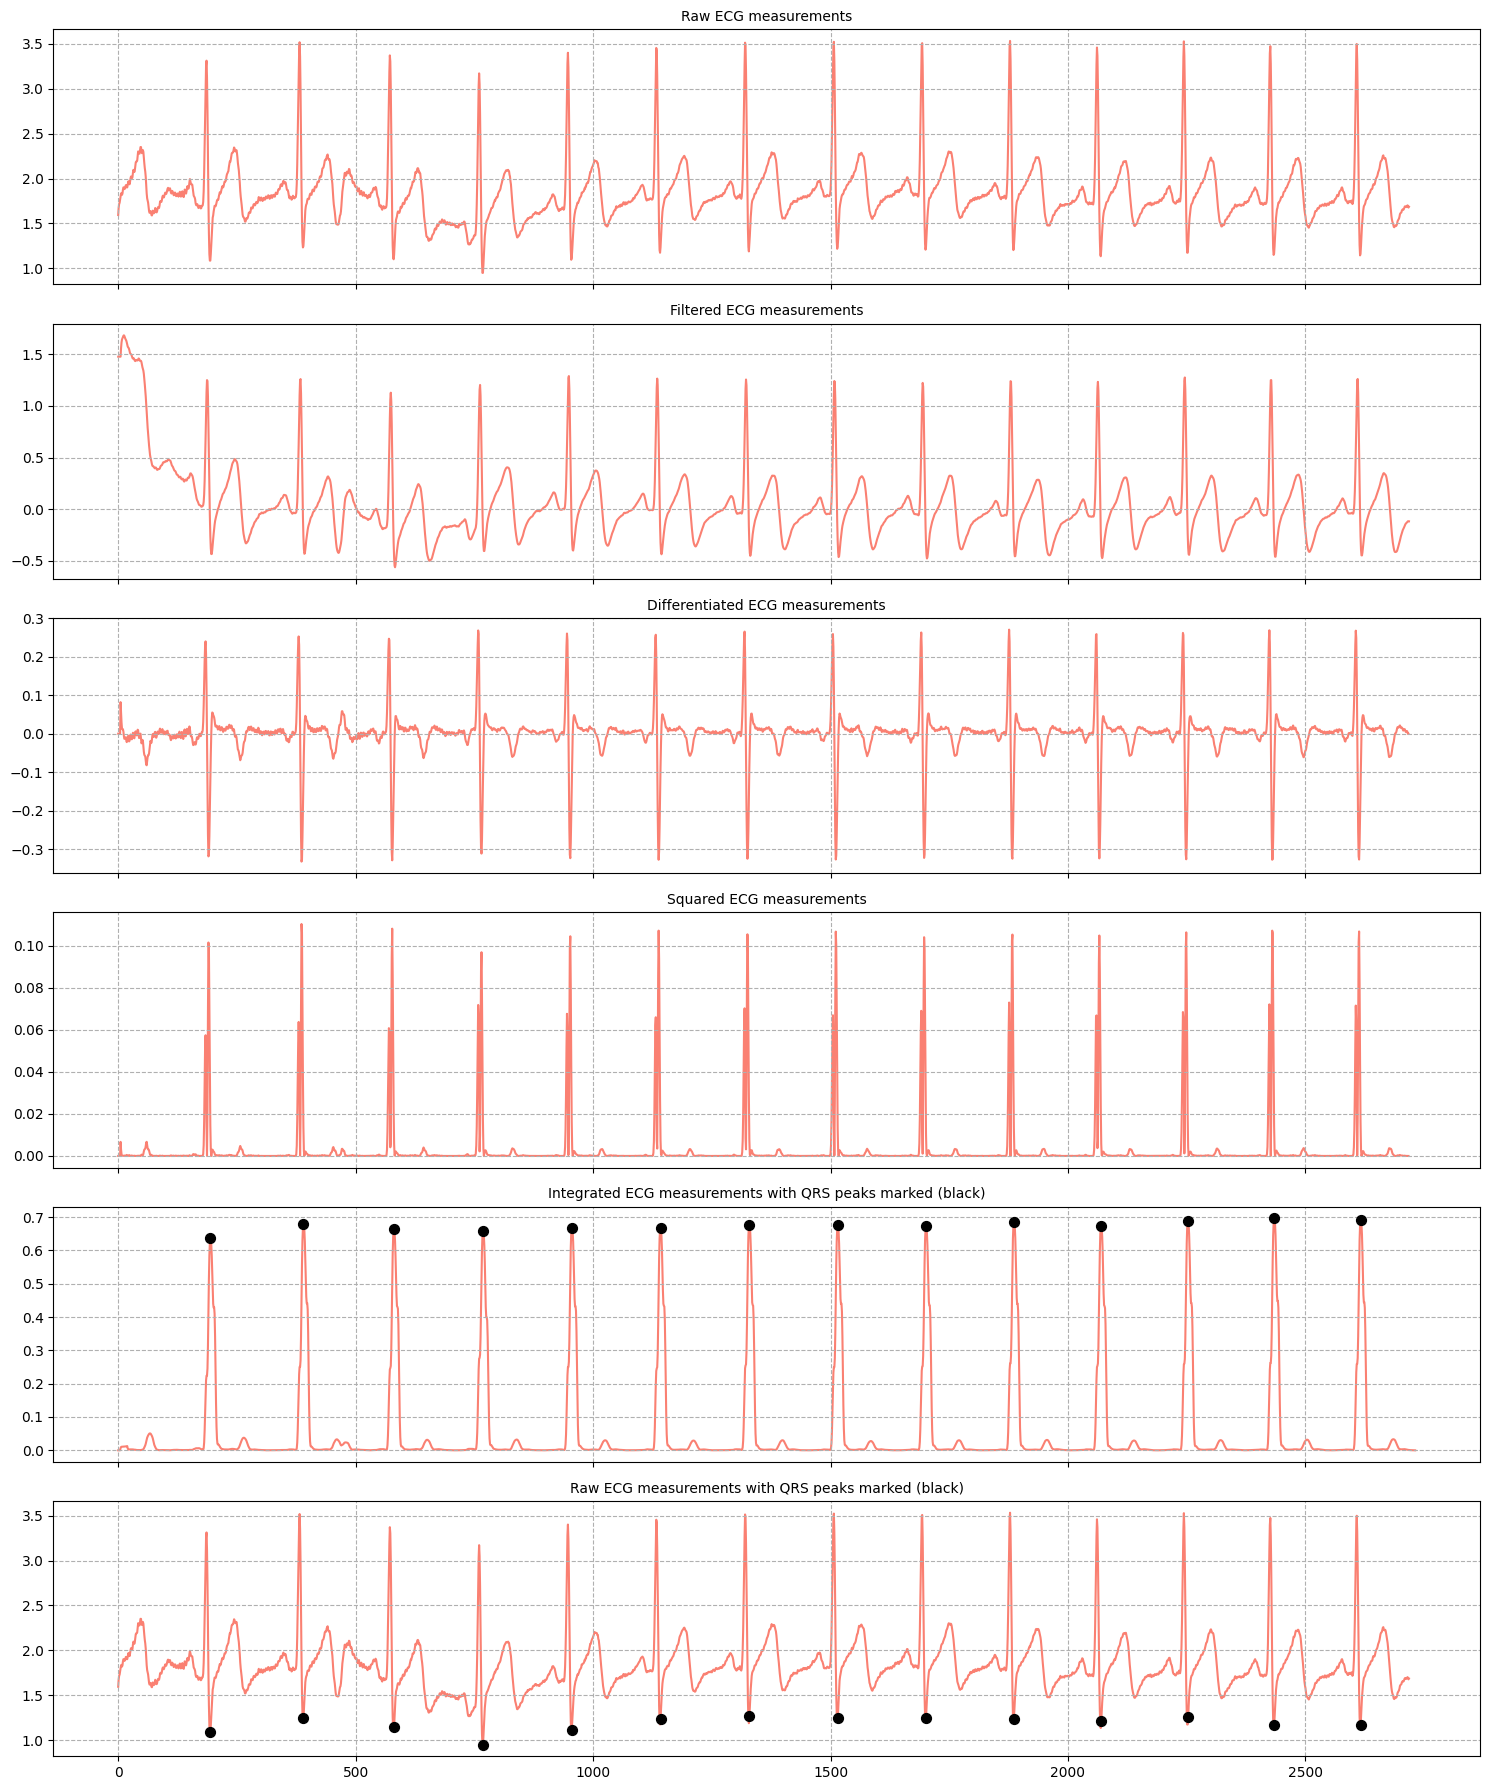

In [2]:
qrs_detector = QRSDetectorOffline(ecg_data_path="ecg_data/ecg_data_1.csv", verbose=True,
                                  log_data=True, plot_data=True, show_plot=True)

## ECG signal with high level of noise

qrs peaks indices
[ 85 282 483 683 874]
noise peaks indices
[]


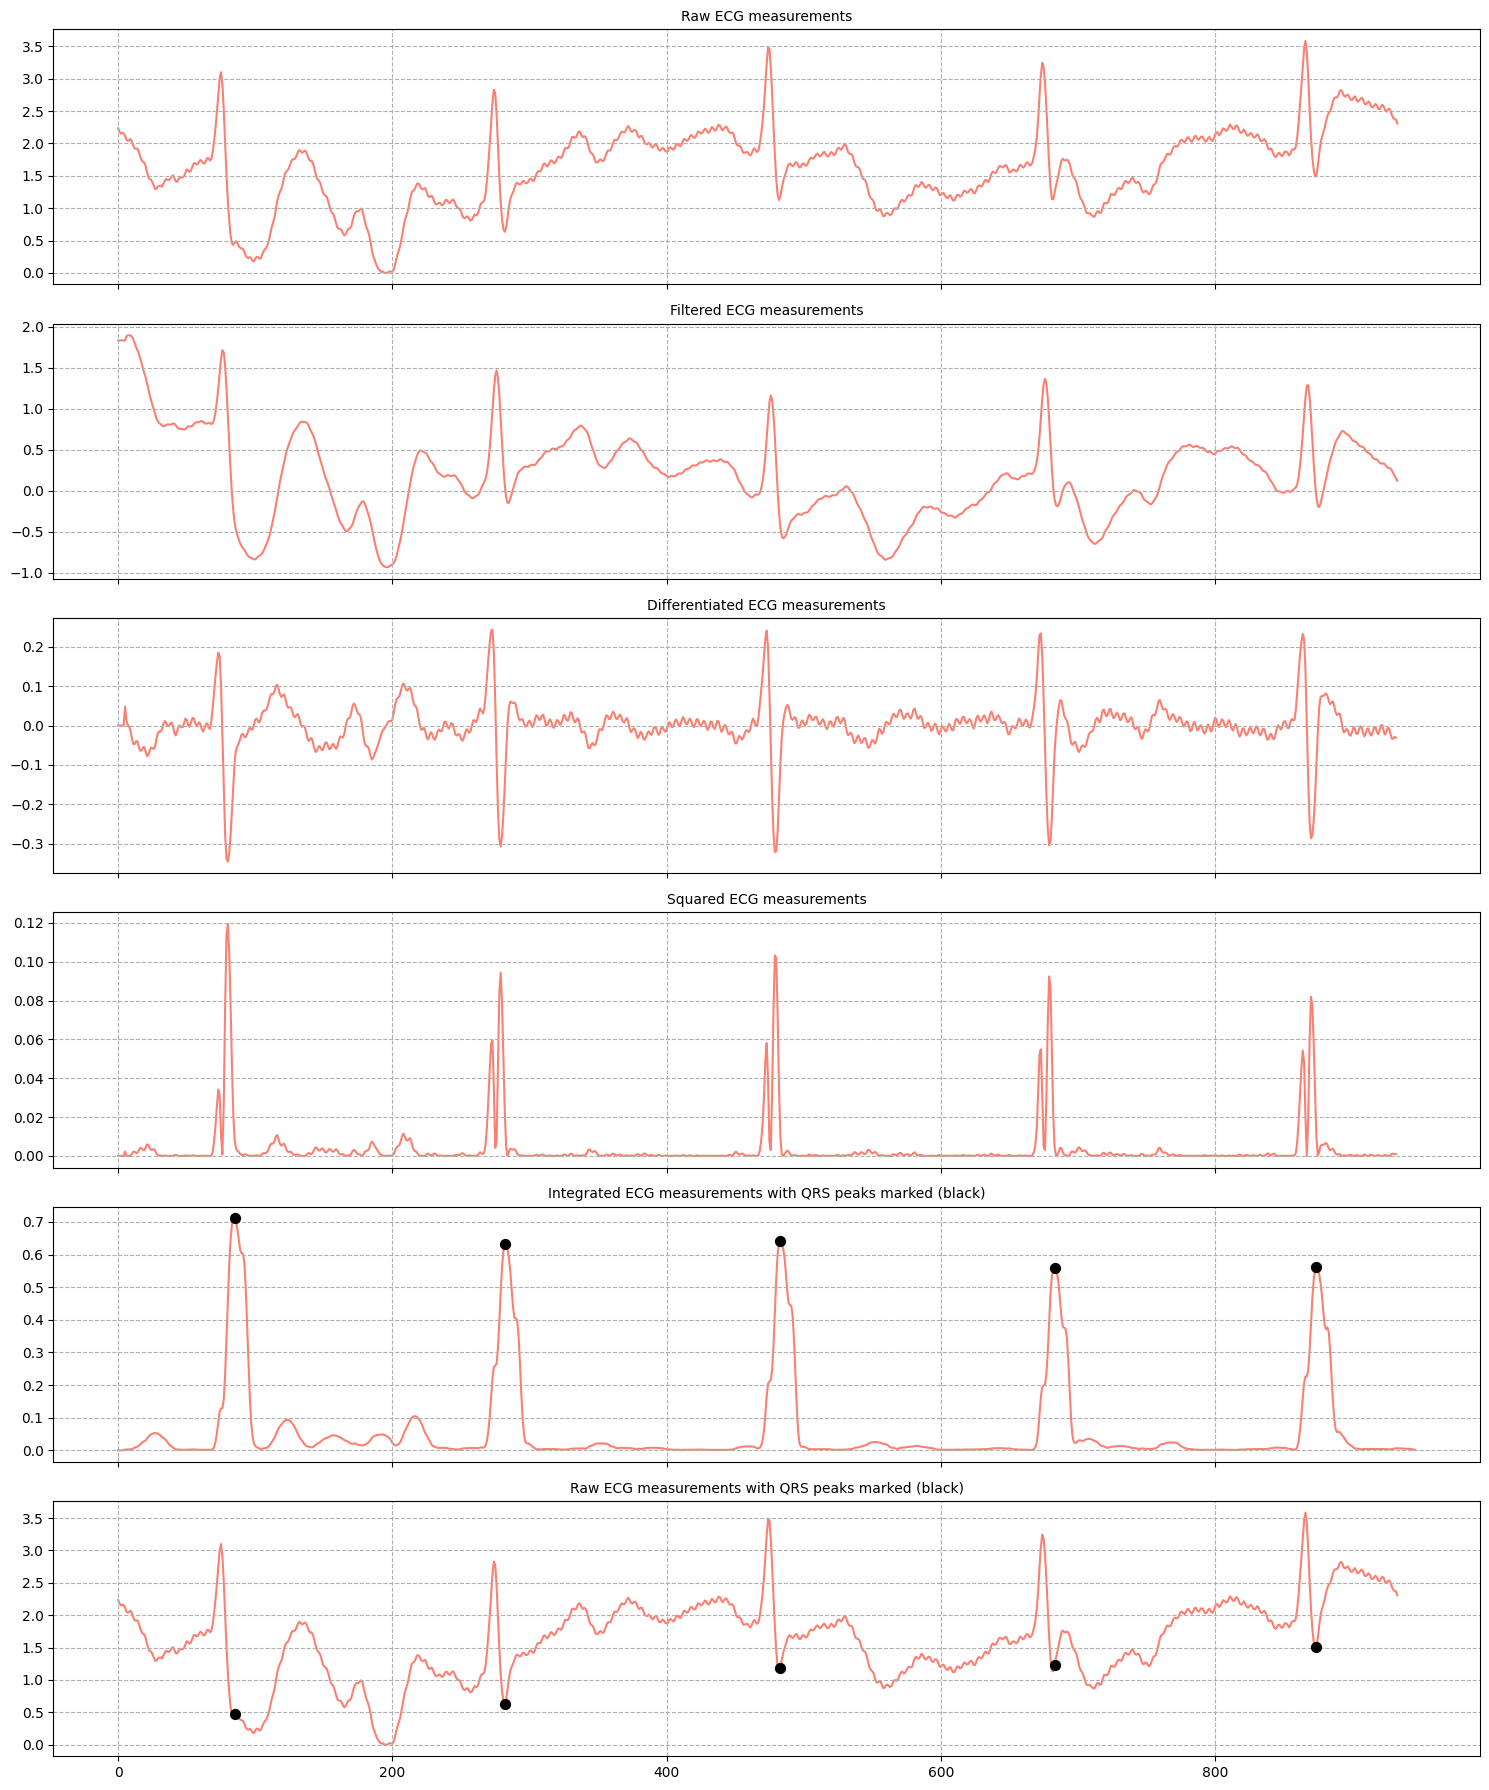

In [3]:
qrs_detector = QRSDetectorOffline(ecg_data_path="ecg_data/ecg_data_2.csv", verbose=True,
                                  log_data=True, plot_data=True, show_plot=True)


--- 关键 HRV 指标 ---
R-R 间隔总数: 4 个
SDNN (所有RR间隔的标准差): 15.59 ms
RMSSD (连续RR间隔差的均方根): 22.86 ms


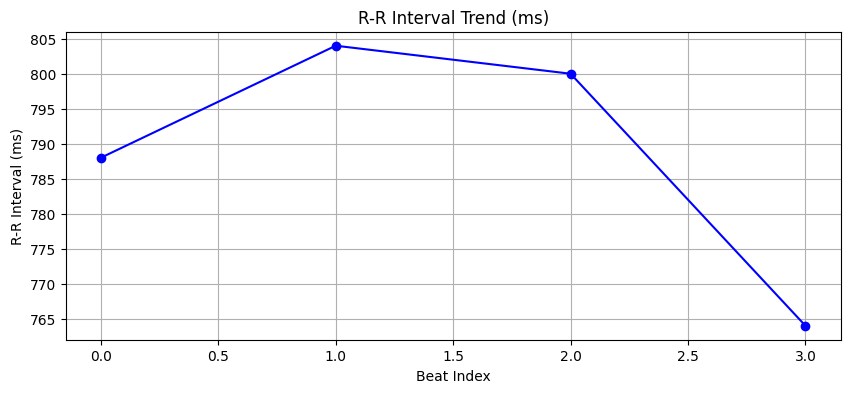

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# 从原始检测器对象中获取R峰的采样点索引
# 即使qrs_detector.detect_peaks()报错，如果它能返回一个空列表或部分结果，代码也能运行
try:
    qrs_indices = np.array(qrs_detector.qrs_peaks_indices)
except AttributeError:
    print("错误：qrs_detector 对象可能未成功初始化或没有 qrs_peaks_indices 属性。")
    print("我们假设未检测到峰值。")
    qrs_indices = np.array([])
    

# 确保索引至少有两个，才能计算间隔
if len(qrs_indices) < 2:
    print("\n--- 关键 HRV 指标 ---")
    print("Not enough R peaks detected to compute HRV.")
    print("原因：QRS 检测算法因 scipy 滤波错误而失败，未能定位 R 峰。")
    print("解决方案：在 CV/Cover Letter 中，只需提及你已成功部署并理解了Pan-Tomkins算法流程。")
    print("此步计算无法完成，但不影响你对项目的理解！")
else:
    # 1. 计算RR间隔 (单位：采样点)
    rr_intervals = np.diff(qrs_indices)
    
    # 假设采样率为 250 Hz (项目默认配置)
    sampling_rate = 250  
    
    # 2. 将RR间隔转换为毫秒 (ms)
    rr_intervals_ms = (rr_intervals / sampling_rate) * 1000
    
    # 3. 计算时间域心率变异性 (HRV) 关键指标
    sdnn = np.std(rr_intervals_ms)
    rr_diff = np.diff(rr_intervals_ms)
    rmssd = np.sqrt(np.mean(rr_diff**2))

    print(f"\n--- 关键 HRV 指标 ---")
    print(f"R-R 间隔总数: {len(rr_intervals_ms)} 个")
    print(f"SDNN (所有RR间隔的标准差): {sdnn:.2f} ms")
    print(f"RMSSD (连续RR间隔差的均方根): {rmssd:.2f} ms")
    
    # 可视化R-R间隔分布
    plt.figure(figsize=(10, 4))
    plt.plot(rr_intervals_ms, marker='o', linestyle='-', color='b')
    plt.title('R-R Interval Trend (ms)')
    plt.xlabel('Beat Index')
    plt.ylabel('R-R Interval (ms)')
    plt.grid(True)
    plt.show()